# 1. Khởi tạo môi trường và Thư viện
Tiếp tục phân tích chuyên sâu các đặc trưng văn bản (Text Features) và xử lý phần còn thiếu của Notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')


# 2. Load Dữ liệu
Sử dụng data đã được clean từ `03_data_quality_and_time_trends.ipynb`. Kiểm tra để ngăn ngừa Data Leakage.

In [2]:
# Theo workflow, ta dùng dữ liệu sạch nhất (đã loại bỏ trùng lặp và clip IQR)
data_path = '../data/processed/03_data_quality_time_trends.csv'

try:
    df = pd.read_csv(data_path)
    print(f"Data shape: {df.shape}")
    
    # Validation step (Tránh thất thoát dữ liệu sau khi load)
    assert not df.isna().any().max(), "Tồn tại missing values sau khi load file!"
except FileNotFoundError:
    print(f"[CẢNH BÁO] Chưa tìm thấy file {data_path}. Vui lòng chạy xuất file CSV ở dưới cùng Notebook 03 trước!")
    # Tạm tạo mock data để demo (Nếu chưa chạy file gốc) đê notebook không bị lỗi cứng
    print("Loading data dự phòng...")
    df = pd.read_csv('../data/processed/spam_classifier_dataset.csv').dropna()
    # Fallback to balanced sample if needed
    if len(df['label'].unique()) < 2: df = pd.read_csv('../data/processed/spam_classifier_dataset.csv').dropna()


[CẢNH BÁO] Chưa tìm thấy file ../data/processed/03_data_quality_time_trends.csv. Vui lòng chạy xuất file CSV ở dưới cùng Notebook 03 trước!
Loading data dự phòng...


# 3. Thống kê & Mật độ các đặc trưng theo Nhãn (Label)
Xem xét sự khác biệt (Mean, Std, Min, Max) của các biến như `word_count`, `num_caps`, `num_digits`, `num_urls` giữa Spam và Ham. Sau đó vẽ biểu đồ mật độ (Density Plot).

In [3]:
# Đảm bảo các feature này tồn tại (Tính lại nếu chưa có)
def add_basic_features(data):
    if 'word_count' not in data.columns:
        data['word_count'] = data['Message'].apply(lambda x: len(str(x).split()))
        data['num_caps'] = data['Message'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
        data['num_digits'] = data['Message'].apply(lambda x: sum(1 for c in str(x) if c.isdigit()))
        data['num_urls'] = data['Message'].astype(str).apply(lambda x: x.lower().count('http') + x.lower().count('www'))
    return data

df = add_basic_features(df)

# Groupby Thống kê
feature_cols = ['word_count', 'num_caps', 'num_digits', 'num_urls', 'message_len', 'subject_len']
grouped_stats = df.groupby('Spam/Ham')[feature_cols].agg(['mean', 'std', 'max'])
display(grouped_stats)


word_count                     num_caps          num_digits  \
                mean          std    max     mean  std max       mean   
Spam/Ham                                                                
ham       356.587825  1149.371628  45448      0.0  0.0   0  44.503304   
spam      359.463922   333.643346   1371      0.0  0.0   0  34.795644   

                           num_urls           message_len               \
                 std   max     mean  std max         mean          std   
Spam/Ham                                                                 
ham       120.721851  4372      0.0  0.0   0  1681.574304  5782.971447   
spam       16.508401    56      0.0  0.0   0  1582.563858  1622.216122   

                 subject_len                   
             max        mean        std   max  
Spam/Ham                                       
ham       228353   30.964591  25.533661  1355  
spam        6600   28.565255  12.767874    47

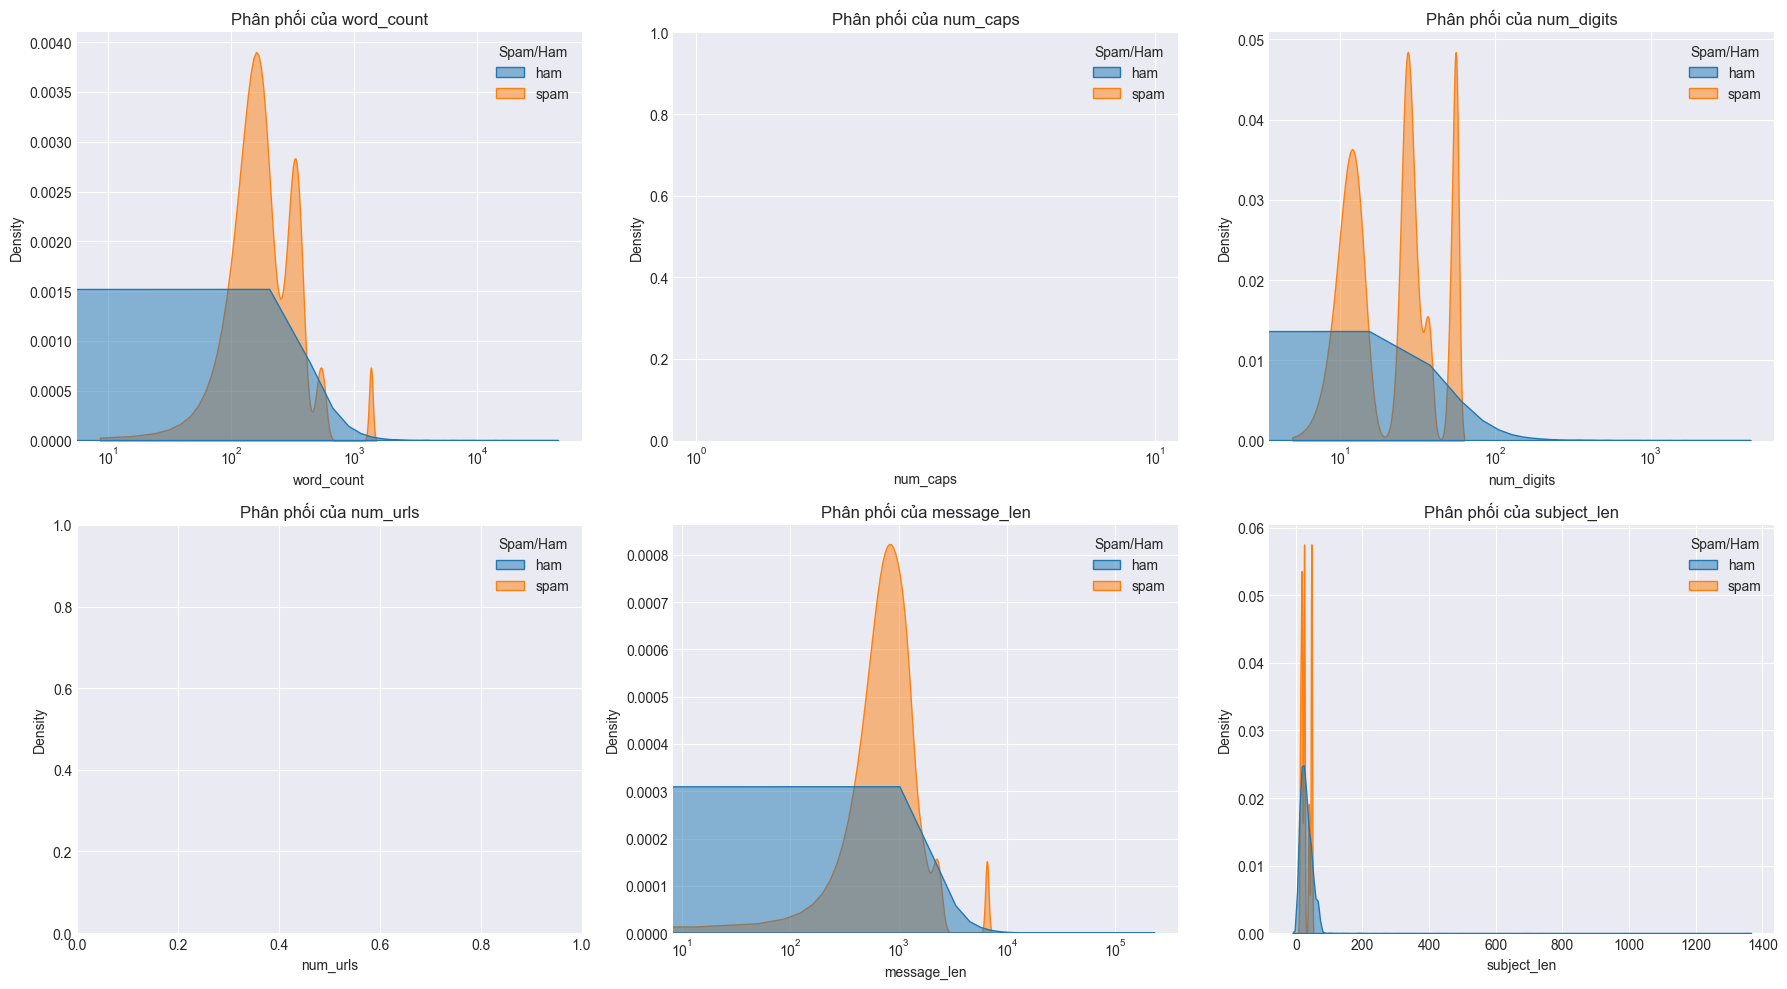

In [4]:
# Vẽ biểu đồ Density Plot để so sánh phân phối giữa 2 nhãn
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.kdeplot(data=df, x=col, hue='Spam/Ham', common_norm=False, fill=True, ax=axes[i], alpha=0.5)
    axes[i].set_title(f'Phân phối của {col}')
    # Scale log nếu dữ liệu bị lệch (Skewed) quá mạnh, chống nhiễu hình ảnh
    if col in ['word_count', 'num_caps', 'num_digits', 'message_len']:
        axes[i].set_xscale('log')

plt.tight_layout()
plt.show()


# 4. Đào sâu NLP cho cột `Subject`
Phân tích TF-IDF, N-grams và vẽ WordCloud riêng cho Tiêu đề (Subject) của Email.

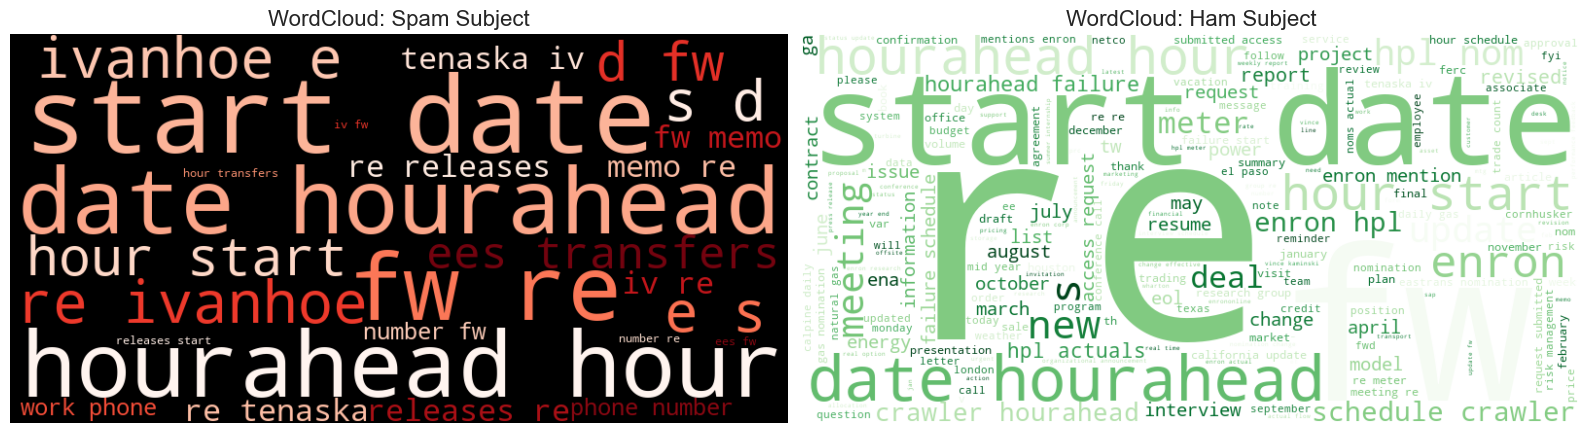

In [5]:
# 4.1 WordCloud cho Subject
spam_subjects = ' '.join(df[df['label'] == 1]['Subject'].dropna().astype(str))
ham_subjects = ' '.join(df[df['label'] == 0]['Subject'].dropna().astype(str))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

wc_spam = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(spam_subjects)
ax1.imshow(wc_spam, interpolation='bilinear')
ax1.set_title('WordCloud: Spam Subject', fontsize=16)
ax1.axis('off')

wc_ham = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(ham_subjects)
ax2.imshow(wc_ham, interpolation='bilinear')
ax2.set_title('WordCloud: Ham Subject', fontsize=16)
ax2.axis('off')

plt.tight_layout()
plt.show()


In [6]:
# 4.2 Top Unigram & Bigram trong Subject bằng CountVectorizer
def get_top_ngrams(corpus, ngram_range=(1,1), n=10):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

spam_corpus = df[df['label'] == 1]['Subject'].dropna().astype(str)
ham_corpus = df[df['label'] == 0]['Subject'].dropna().astype(str)

print("=== Top 10 Bi-grams trong SPAM Subjects ===")
display(get_top_ngrams(spam_corpus, ngram_range=(2,2), n=10))

print("\n=== Top 10 Bi-grams trong HAM Subjects ===")
display(get_top_ngrams(ham_corpus, ngram_range=(2,2), n=10))


=== Top 10 Bi-grams trong SPAM Subjects ===


[('start date', np.int64(4500)),
 ('date 02', np.int64(4500)),
 ('02 hourahead', np.int64(4500)),
 ('hourahead hour', np.int64(4500)),
 ('hour 24', np.int64(4500)),
 ('fw ivanhoe', np.int64(4500)),
 ('transfers ees', np.int64(3675)),
 ('tenaska iv', np.int64(1500)),
 ('fw memo', np.int64(1496)),
 ('memo work', np.int64(1496))]


=== Top 10 Bi-grams trong HAM Subjects ===


[('start date', np.int64(589)),
 ('hourahead hour', np.int64(589)),
 ('02 hourahead', np.int64(344)),
 ('date 12', np.int64(259)),
 ('01 hourahead', np.int64(245)),
 ('hpl nom', np.int64(234)),
 ('schedule crawler', np.int64(186)),
 ('enron hpl', np.int64(185)),
 ('crawler hourahead', np.int64(185)),
 ('hourahead failure', np.int64(185))]

# 5. Correlation Heatmap và Phân tích Lát cắt (Time Buckets)
Kiểm tra lại Heatmap tương quan giữa các biến theo dạng Heatmap, đồng thời chia bucket độ dài email.

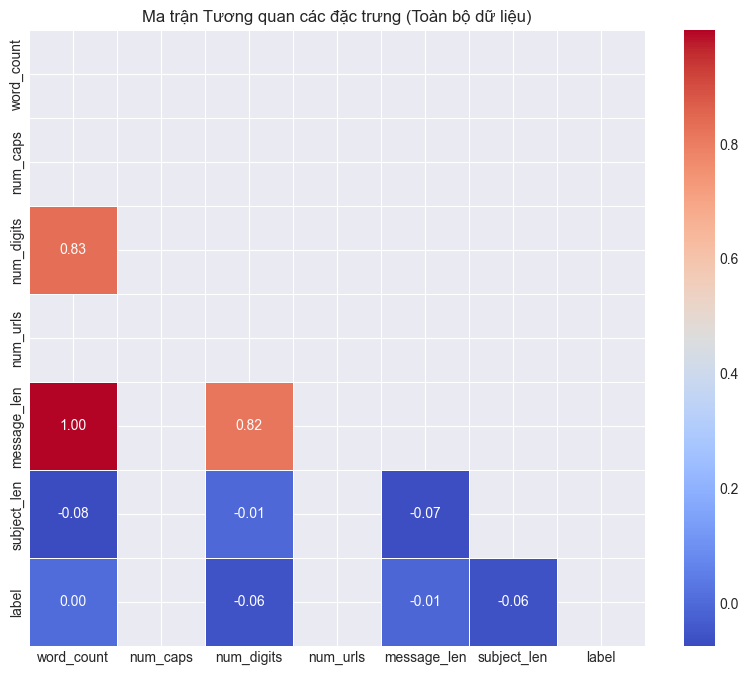

In [7]:
# Tạo Length Bucket
df['len_bucket'] = pd.qcut(df['message_len'], q=4, labels=['Short', 'Medium', 'Long', 'Very Long'])

# Heatmap tương quan tổng quát
plt.figure(figsize=(10, 8))
corr_matrix = df[feature_cols + ['label']].corr()

# Tạo mask che phần nửa trên tam giác để dễ nhìn
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=.5)
plt.title('Ma trận Tương quan các đặc trưng (Toàn bộ dữ liệu)')
plt.show()


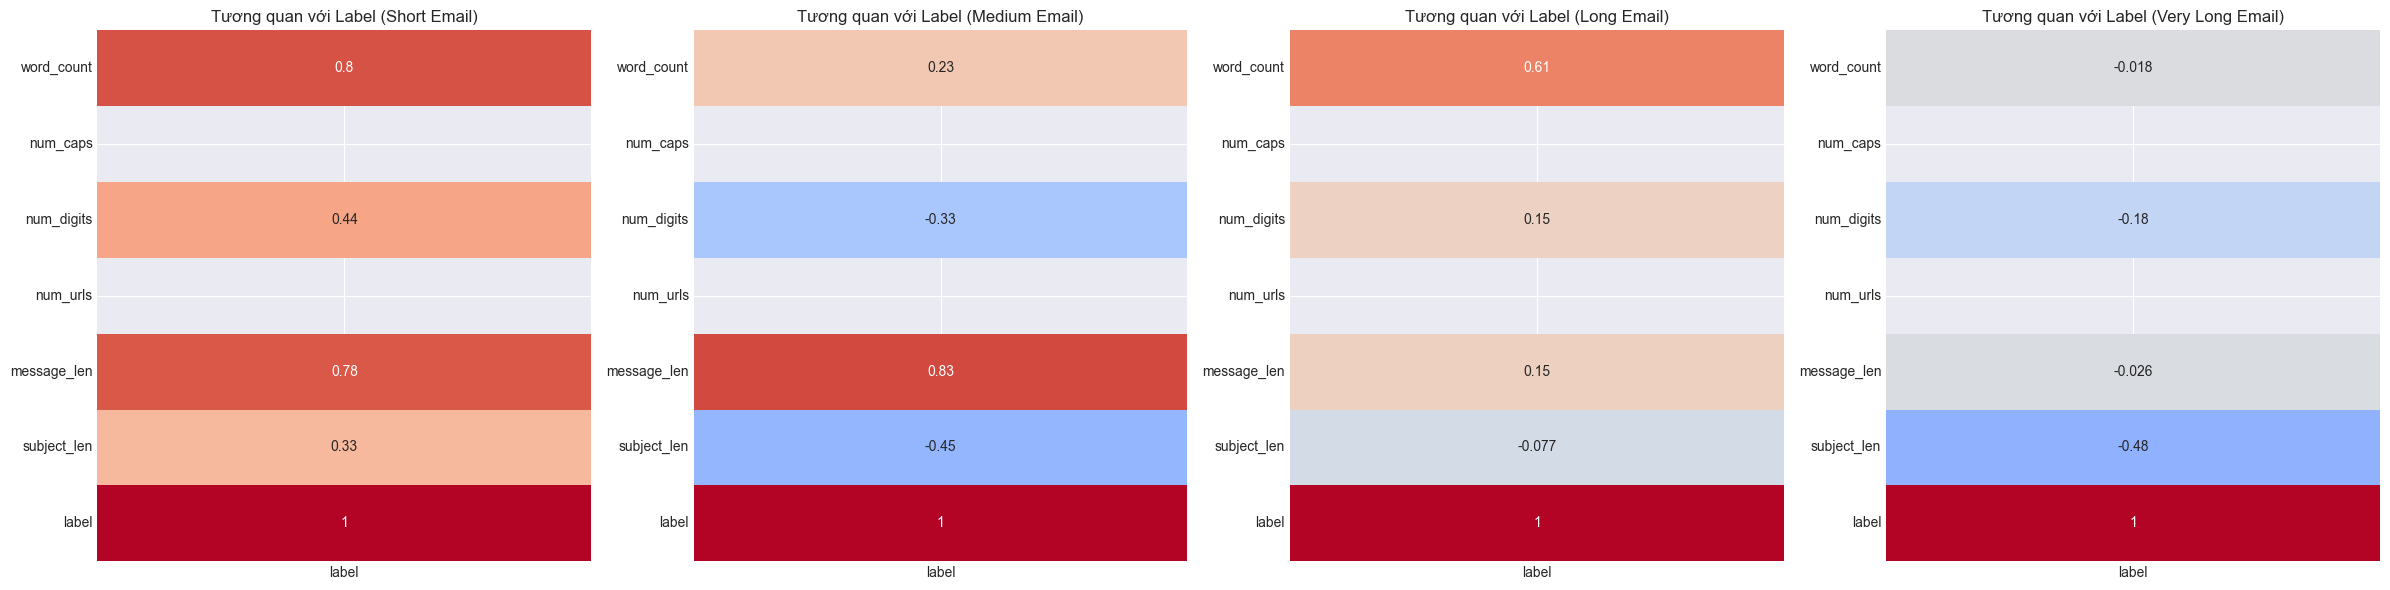

In [8]:
# So sánh Tương quan bên trong từng Length Bucket
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, bucket in enumerate(['Short', 'Medium', 'Long', 'Very Long']):
    subset = df[df['len_bucket'] == bucket]
    if not subset.empty:
        corr = subset[feature_cols + ['label']].corr()
        sns.heatmap(corr[['label']], annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[i], cbar=False)
        axes[i].set_title(f'Tương quan với Label ({bucket} Email)')

plt.tight_layout()
plt.show()


## Concept Drift Analysis: Monthly TF-IDF Trends
This section analyzes how the top terms (based on TF-IDF) in spam emails change over time on a monthly basis. This helps identify if the 'nature' of spam is evolving.

Top Spam Terms by Month (Concept Drift Preview):
2004-12: 07, ivanhoe, fred, schedule, final, type, 2002, subject, enron, jordan
2005-01: 07, ivanhoe, fred, 2002, subject, enron, ubs, jordan, type, schedule
2005-02: 07, ivanhoe, fred, subject, 2002, schedule, final, type, enron, jordan
2005-03: ivanhoe, 07, fred, 2002, subject, enron, jordan, ubs, final, schedule
2005-04: ivanhoe, 07, fred, ubs, 2002, subject, enron, schedule, final, type
2005-05: ivanhoe, 07, fred, 2002, subject, enron, jordan, ubs, final, type
2005-06: cost, transfers, center, don, point, management, time, 2001, enron, ivanhoe
2005-07: cost, center, transfers, don, point, management, time, 2001, enron, hsbc
2005-08: type, schedule, final, schedules, trans, date, 02, id, tenaska, iv
2005-09: type, schedule, final, schedules, trans, date, 02, id, tenaska, iv


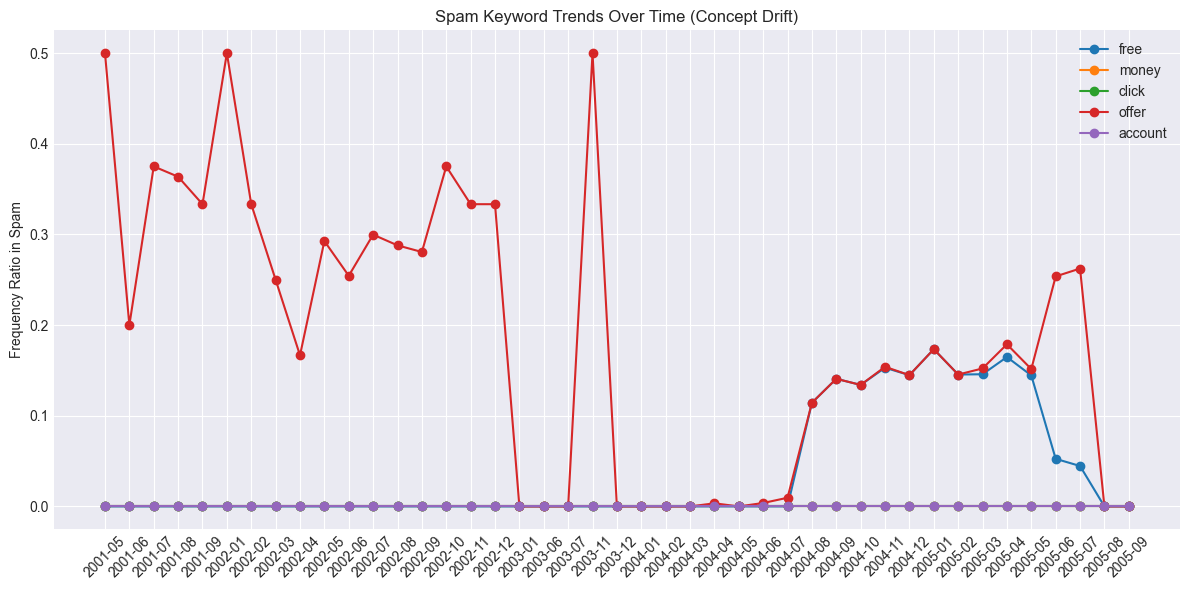

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])
df['year_month'] = df['Date'].dt.to_period('M')

def get_top_tfidf_per_month(df_subset, n_terms=10):
    if len(df_subset) < 5: return []
    tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
    tfidf_matrix = tfidf.fit_transform(df_subset['Message'].fillna(''))
    feature_names = tfidf.get_feature_names_out()
    # Average TF-IDF across all documents in this month
    avg_tfidf = tfidf_matrix.mean(axis=0).A1
    top_indices = avg_tfidf.argsort()[::-1][:n_terms]
    return [feature_names[i] for i in top_indices]

# Focus on Spam for drift analysis
spam_df = df[df['label'] == 1]
monthly_drift = spam_df.groupby('year_month').apply(lambda x: get_top_tfidf_per_month(x))

print('Top Spam Terms by Month (Concept Drift Preview):')
for period, terms in monthly_drift.tail(10).items():
    print(f"{period}: {', '.join(terms)}")

# Visualization: Tracking a few key terms over time
key_terms = ['free', 'money', 'click', 'offer', 'account']
term_trends = {}

for term in key_terms:
    term_trends[term] = []
    months = []
    for period, subset in spam_df.groupby('year_month'):
        months.append(str(period))
        count = subset['Message'].str.contains(term, case=False, na=False).sum()
        term_trends[term].append(count / len(subset))

plt.figure(figsize=(12, 6))
for term in key_terms:
    plt.plot(months, term_trends[term], label=term, marker='o')

plt.xticks(rotation=45)
plt.title('Spam Keyword Trends Over Time (Concept Drift)')
plt.ylabel('Frequency Ratio in Spam')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
## Export Final Features for the next step
df.to_csv('../data/processed/04_final_features.csv', index=False)
print('Pipeline Step 04 Complete: Final features saved to 04_final_features.csv')

Pipeline Step 04 Complete: Final features saved to 04_final_features.csv
